<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#PyTorch.-Основы:-синтаксис,-torch.cuda-и-torch.autograd" data-toc-modified-id="PyTorch.-Основы:-синтаксис,-torch.cuda-и-torch.autograd-1"><span class="toc-item-num">1&nbsp;&nbsp;</span><b>PyTorch. Основы: синтаксис, torch.cuda и torch.autograd</b></a></span><ul class="toc-item"><li><span><a href="#Задача-1" data-toc-modified-id="Задача-1-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Задача 1</a></span></li><li><span><a href="#Задача-2" data-toc-modified-id="Задача-2-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Задача 2</a></span></li><li><span><a href="#Задача-3" data-toc-modified-id="Задача-3-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Задача 3</a></span></li><li><span><a href="#Задача-4" data-toc-modified-id="Задача-4-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Задача 4</a></span></li><li><span><a href="#Задача-5" data-toc-modified-id="Задача-5-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>Задача 5</a></span></li></ul></li></ul></div>

---

<h2 style="text-align: center;"><b>PyTorch. Основы: синтаксис, torch.cuda и torch.autograd</b></h2>

<p style="align: center;"><img src="https://raw.githubusercontent.com/pytorch/pytorch/master/docs/source/_static/img/pytorch-logo-dark.png", width=400, height=300></p>

---

In [2]:
import torch
import matplotlib.pyplot as plt

### Задача 1

1). Создайте два вещественных тензора: `a` размером (3, 4) и `b` размером (12,)   
2). Создайте тензор `c`, являющийся тензором `b`, но размера (2, 2, 3)  
3). Выведите первый столбец матрицы `a` с помощью индексации

In [13]:
a = torch.FloatTensor(3, 4)
b = torch.FloatTensor(12)
c = b.view(2, 2, 3)
print(a[:, 0])

tensor([0., 0., 0.])


### Задача 2

1). Создайте два вещественных тензора: `a` размером (5, 2) и `b` размером (1,10)   
2). Создайте тензор `c`, являющийся тензором `b`, но размера (5, 2)  
3). Произведите все арифметические операции с тензорами `a` и `c`

In [ ]:
a = torch.FloatTensor(5, 2)
b = torch.FloatTensor(1, 10)
c = b.view(5, 2)

a.add(c)
a.sub(c)
a.mul(c)
a.div(c)

### Задача 3

1). Создайте тензор *целых чисел* `images` размерности (100, 200, 200, 3) (можно интерпретировать это как 100 картинок размера 200х200 с тремя цветовыми каналами, то есть 100 цветных изображений 200х200). Заполните его нулями  

2). Сделайте так, чтобы у $i$-ой по порядку картинки была нарисована белая полоса толщиной два пикселя в строках, которые соответствуют номеру картинки. Например, у 3-ей по порядку картинки белая полоска будет занимать 6 и 7 строки, у 99 -- 198 и 199. Сделать белую строку можно, записав в ячейки тензора число 255 (по всем трём каналам). Выведите пару примеров с помощоью `pylot`  

3). Посчитайте среднее тензора `images` по 1-ой оси (по сути - средняя картинка), умножьте полученный тензор на 70. Нарисуйте с помощью `pyplot`, должна получиться серая картинка (при взятии среднего нужно привести тензор к float с помощью `.float()`, при отрисовке обратно к int с помощью `.int()`)

In [ ]:
images=torch.IntTensor(100, 200, 200, 3)
images.zero_()

for i in range(100):
    images[i, 2*i:2*i+2, :, :] = 255

plt.imshow(images[5].numpy())
plt.show()
plt.imshow(images[60].numpy())
plt.show()

flim=images.float()
flmean=flim.mean(0)
flmean=flmean.mul(70)
immean=flmean.int()

plt.imshow(immean.numpy())
plt.show()

### Задача 4

Перейдите на Google Colaboratory, чтобы работать с GPU. Загрузите туда этот ноутбук (Upload notebook)
В Colab нажмите в меню сверху: Runtime -> Change Runtime Type -> GPU, где изначально стоит None
Объявите тензор a размера (2, 3, 4) и тензор b размера (1, 8, 3) на GPU, иницилизируйте их случайно равномерно (.uniform_())
Затем измените форму тензора b, чтобы она совпадала с формой тензора a, получите тензор c
Переместите c на CPU, переместите a на CPU
Оберните их в Variable()
Объявите тензор L = torch.mean((c - a) ** 2) и посчитайте градиент L по c ( то есть  ∂𝐿∂𝑐)
 
Выведите градиент L по c

In [ ]:
import torch

print(torch.cuda.is_available())

a = torch.empty((2, 3, 4), dtype=torch.float32, device='cuda').uniform_(0, 1)
b = torch.empty((1, 8, 3), dtype=torch.float32, device='cuda').uniform_(0, 1)

c = b.view(2, 3, 4)

a = a.cpu()
c = c.cpu()


a.requires_grad_(False)
c.requires_grad_(True)

L = torch.mean((c - a) ** 2)
L.backward()

print(c.grad)

False


AssertionError: Torch not compiled with CUDA enabled

### Задача 5

Доработайте многослойную нейронную сеть из файла "4_3 mlp pytorch tasks".

In [ ]:
import numpy as np

N = 100
D = 2
K = 3
X = np.zeros((N * K, D))
y = np.zeros(N * K, dtype='uint8')

for j in range(K):
    ix = range(N * j,N * (j + 1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j * 4, (j + 1) * 4,N) + np.random.randn(N) * 0.2 # theta
    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y[ix] = j

X = torch.autograd.Variable(torch.FloatTensor(X))
y = torch.autograd.Variable(torch.LongTensor(y.astype(np.int64)))

# N - размер батча (batch_size, нужно для метода оптимизации); 
# D_in - размерность входа (количество признаков у объекта);
# H - размерность скрытых слоёв; 
# D_out - размерность выходного слоя (суть - количество классов)
N, D_in, H, D_out = 64, 2, 100, 3




modif_net = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out)
)

loss_fn = torch.nn.CrossEntropyLoss(size_average=False)

learning_rate = 1e-2
optimizer = torch.optim.Adam(modif_net.parameters(), lr=learning_rate)
for t in range(2000):
    # forward
    y_pred = modif_net(X)

    # loss
    loss = loss_fn(y_pred, y)
    print('{} {}'.format(t, loss.data))

    # зануляем градиенты (чтобы не было остатка с редыдущего шага)
    optimizer.zero_grad()

    # backward
    loss.backward()

    # обновляем
    optimizer.step()

d:\anaconda\Lib\site-packages\torch\nn\modules\loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


0 326.4556579589844
1 296.046142578125
2 269.9550476074219
3 246.78651428222656
4 228.40016174316406
5 215.64337158203125
6 208.6526641845703
7 203.6083526611328
8 199.28013610839844
9 193.29644775390625
10 186.0516815185547
11 177.319580078125
12 167.71644592285156
13 157.46441650390625
14 147.16163635253906
15 136.94163513183594
16 127.21891021728516
17 117.8447036743164
18 108.9561538696289
19 100.17937469482422
20 91.70034790039062
21 83.47329711914062
22 75.78486633300781
23 68.86370849609375
24 62.7652587890625
25 57.34630584716797
26 52.458744049072266
27 48.078887939453125
28 44.05055618286133
29 40.4078369140625
30 37.121883392333984
31 34.24659729003906
32 31.689908981323242
33 29.416433334350586
34 27.382402420043945
35 25.556278228759766
36 23.93180274963379
37 22.469139099121094
38 21.186609268188477
39 20.044445037841797
40 19.04123306274414
41 18.132396697998047
42 17.315561294555664
43 16.57769775390625
44 15.904861450195312
45 15.299116134643555
46 14.741300582885742
4

C:\Users\NND01\AppData\Local\Temp\ipykernel_15528\3868953030.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
C:\Users\NND01\AppData\Local\Temp\ipykernel_15528\3868953030.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, h))


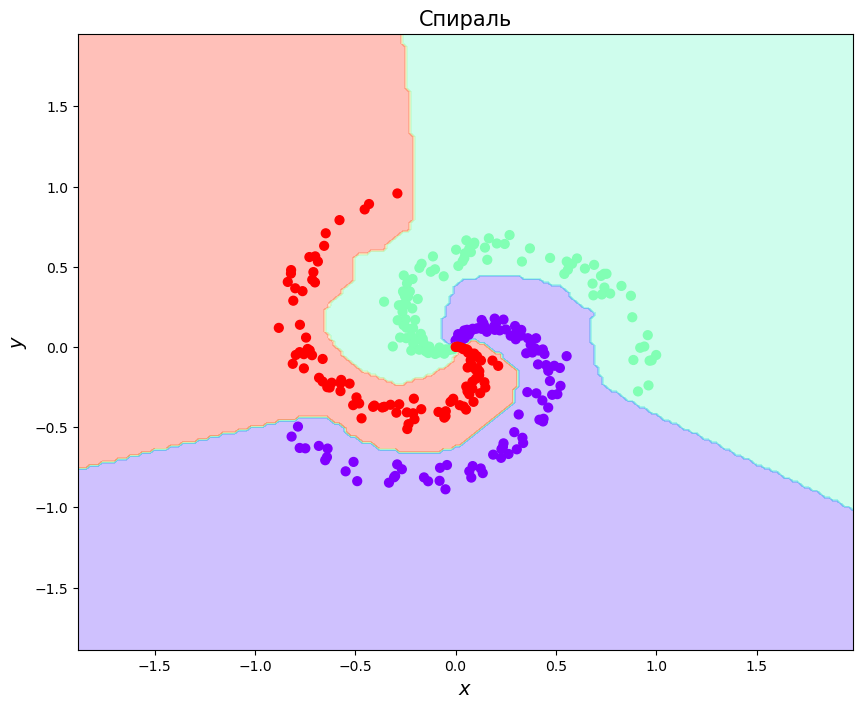

In [5]:
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

Z = modif_net(torch.autograd.Variable(grid_tensor))
Z = Z.data.numpy()
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z, cmap=plt.cm.rainbow, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.rainbow)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

plt.title('Спираль', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show();